# Hierarchical Energy Futures Pricing with Latent Sentiment
## Modeling asynchronous trades across country-tenor instruments


In [3]:

import numpy as np
import pandas as pd
from scipy.stats import multivariate_normal
import matplotlib.dates as mdates
from matplotlib import pyplot as plt
from numpy.linalg import inv



## 1. Synthetic Data Generation
Simulating market microstructure with:
- 3 Countries (DE, FR, IT)
- 3 Tenors (m24, q1, y1)
- Latent sentiment process
- Bid/ask spread dynamics


In [4]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

class TradeSimulator:
    def __init__(self):
        self.instruments = ['DE', 'FR', 'IT']
        self.tenors = ['m1', 'm2', 'm3', 'q1', 'q2', 'q3', 'q4', 'y1', 'y2']
        # Base prices and daily volumes (EUR/MWh)
        self.market_data = {
            'DE': {
                'm1': {'base': 70.5, 'daily_volume': 4400},
                'm2': {'base': 72.0, 'daily_volume': 2800},
                'm3': {'base': 73.5, 'daily_volume': 159},
                'q1': {'base': 75.0, 'daily_volume': 1100},
                'q2': {'base': 77.0, 'daily_volume': 650},
                'q3': {'base': 79.0, 'daily_volume': 255},
                'q4': {'base': 81.0, 'daily_volume': 45},
                'y1': {'base': 85.0, 'daily_volume': 666},
                'y2': {'base': 88.0, 'daily_volume': 140}
            },
            'FR': {
                'm1': {'base': 31.5, 'daily_volume': 887},
                'm2': {'base': 32.0, 'daily_volume': 699},
                'm3': {'base': 32.5, 'daily_volume': 72},
                'q1': {'base': 33.0, 'daily_volume': 465},
                'q2': {'base': 34.0, 'daily_volume': 123},
                'y1': {'base': 38.0, 'daily_volume': 43}
            },
            'IT': {
                'm1': {'base': 98.0, 'daily_volume': 91},
                'q1': {'base': 101.0, 'daily_volume': 92}
            }
        }
        # Trade size distributions
        self.trade_size_dist = {
            'monthly': [0.9, 0.04, 0.03, 0.03],  # 1,2,3,5 lots
            'other': [0.98, 0.01, 0.01]          # 1,2,3 lots
        }
        # Sentiment sensitivity coefficients
        self.sentiment_coeff = {
            'm1': 1.8, 'm2': 1.7, 'm3': 1.6,
            'q1': 1.5, 'q2': 1.4, 'q3': 1.3, 'q4': 1.2,
            'y1': 1.1, 'y2': 0.9
        }
        self._calculate_liquidity_ratios()
        self.S = None
        self.corr = 0.95  # Cross-market correlation
        self.order_books = self._init_order_books()
        
    def _calculate_liquidity_ratios(self):
        max_vol = max(v['daily_volume'] for country in self.market_data.values() for v in country.values())
        for country in self.market_data.values():
            for tenor_data in country.values():
                tenor_data['liquidity_ratio'] = tenor_data['daily_volume'] / max_vol

    def _get_trade_size(self, tenor):
        if tenor.startswith('m'):
            return np.random.choice([1,2,3,5], p=self.trade_size_dist['monthly'])
        return np.random.choice([1,2,3], p=self.trade_size_dist['other'])

    def simulate_latent_sentiment(self, num_ticks=1000):
        # Simulate 3 highly correlated latent sentiments for DE, FR, IT
        dt = 1/num_ticks
        theta = 0.15
        mu = 0.0
        sigma = 0.25
        # Correlated Brownian increments
        L = np.linalg.cholesky(np.array([
            [1.0, self.corr, self.corr],
            [self.corr, 1.0, self.corr],
            [self.corr, self.corr, 1.0]
        ]))
        dW = np.random.normal(size=(num_ticks-1, 3)) * np.sqrt(dt)
        dW_corr = dW @ L.T
        S = np.zeros((num_ticks, 3))
        for t in range(1, num_ticks):
            for i in range(3):
                S[t,i] = S[t-1,i] + theta*(mu - S[t-1,i])*dt + sigma*dW_corr[t-1,i]
        self.S = S  # Shape: (num_ticks, 3)
        return self.S

    def _init_order_books(self):
        books = {}
        for i, inst in enumerate(self.instruments):
            books[inst] = {}
            for tenor in self.tenors:
                if tenor in self.market_data.get(inst, {}):
                    base = self.market_data[inst][tenor]['base']
                    books[inst][tenor] = {'bid': base-0.05, 'ask': base+0.05, 'mid': base}
        return books

    def _apply_cross_market_impact(self, inst_idx, tenor, price_change, t_idx):
        # Propagate 95% of price change to other markets, without modifying sentiment
        for j, other_inst in enumerate(self.instruments):
            if j != inst_idx and tenor in self.order_books[other_inst]:
                # Apply 95% of the price change to mid, bid, ask
                impact = price_change * self.corr
                for k in ['mid', 'bid', 'ask']:
                    self.order_books[other_inst][tenor][k] += impact

    def generate_trades(self, num_events=5000):
        if self.S is None:
            self.simulate_latent_sentiment()
        
        base_date = datetime(2025, 4, 29)  # Or use any date you like
        times = np.cumsum(np.random.exponential(scale=0.1, size=num_events))
        data = []
        last_trade_price = {}
        
        for t in times:
            all_pairs = []
            weights = []
            for inst in self.instruments:
                for tenor in self.market_data.get(inst, {}):
                    all_pairs.append((inst, tenor))
                    weights.append(self.market_data[inst][tenor]['liquidity_ratio'])
            weights = np.array(weights) / sum(weights)
            trade_pair_idx = np.random.choice(len(all_pairs), p=weights)
            trade_inst, trade_tenor = all_pairs[trade_pair_idx]
            t_idx = min(int(t*10), self.S.shape[0]-1)
            inst_idx = self.instruments.index(trade_inst)
            mdata = self.market_data[trade_inst][trade_tenor]
            size = self._get_trade_size(trade_tenor)
            price_impact = size * (1 - mdata['liquidity_ratio']) * 0.01
            base_price = mdata['base'] + self.S[t_idx, inst_idx] * self.sentiment_coeff[trade_tenor]
            price = round(base_price * (1 + price_impact) + np.random.normal(0, 0.05), 2)
            self.order_books[trade_inst][trade_tenor]['mid'] = price
            self.order_books[trade_inst][trade_tenor]['bid'] = round(price - 0.05, 2)
            self.order_books[trade_inst][trade_tenor]['ask'] = round(price + 0.05, 2)
            pair_key = (trade_inst, trade_tenor)
            prev_price = last_trade_price.get(pair_key, price)
            last_trade_price[pair_key] = price
            price_change = price - prev_price
            if abs(price_change) > 0.001:
                self._apply_cross_market_impact(inst_idx, trade_tenor, price_change, t_idx)
            
            # Convert float seconds to datetime
            dt_timestamp = base_date + timedelta(seconds=t)
            data.append({
                'timestamp': dt_timestamp,
                'instrument': trade_inst,
                'tenor': trade_tenor,
                'price': price,
                'size': size,
                'bid': self.order_books[trade_inst][trade_tenor]['bid'],
                'ask': self.order_books[trade_inst][trade_tenor]['ask'],
                'liquidity_ratio': mdata['liquidity_ratio'],
                'type': 'trade'
            })
            for inst, tenor in all_pairs:
                if (inst, tenor) != (trade_inst, trade_tenor):
                    data.append({
                        'timestamp': dt_timestamp,
                        'instrument': inst,
                        'tenor': tenor,
                        'price': np.nan,
                        'size': np.nan,
                        'bid': self.order_books[inst][tenor]['bid'],
                        'ask': self.order_books[inst][tenor]['ask'],
                        'liquidity_ratio': self.market_data[inst][tenor]['liquidity_ratio'],
                        'type': 'quote'
                    })
        df = pd.DataFrame(data).sort_values('timestamp')
        df['instrument_tenor'] = df['instrument'] + '_' + df['tenor']
        df['mid'] = (df['bid'] + df['ask']) * 0.5
        return df



# Example usage
if __name__ == "__main__":
    sim = TradeSimulator()
    sim.simulate_latent_sentiment()
    df = sim.generate_trades(2000)
    print(df.head(10))
    # Example: get all DE m1 trades
    print(df[(df.instrument=='DE') & (df.tenor=='m1') & (df.type=='trade')].head())


                    timestamp instrument tenor  price  size     bid     ask  \
0  2025-04-29 00:00:00.027024         DE    q1  75.59   1.0   75.54   75.64   
16 2025-04-29 00:00:00.027024         IT    q1    NaN   NaN  100.95  101.05   
15 2025-04-29 00:00:00.027024         IT    m1    NaN   NaN   97.95   98.05   
14 2025-04-29 00:00:00.027024         FR    y1    NaN   NaN   37.95   38.05   
13 2025-04-29 00:00:00.027024         FR    q2    NaN   NaN   33.95   34.05   
11 2025-04-29 00:00:00.027024         FR    m3    NaN   NaN   32.45   32.55   
10 2025-04-29 00:00:00.027024         FR    m2    NaN   NaN   31.95   32.05   
9  2025-04-29 00:00:00.027024         FR    m1    NaN   NaN   31.45   31.55   
12 2025-04-29 00:00:00.027024         FR    q1    NaN   NaN   32.95   33.05   
7  2025-04-29 00:00:00.027024         DE    y1    NaN   NaN   84.95   85.05   

    liquidity_ratio   type instrument_tenor     mid  
0          0.250000  trade            DE_q1   75.59  
16         0.020909  q

## Load real data

## 2. Data Structure Visualization
Plotting the hierarchical relationships and asynchronous observations


In [5]:
df.groupby(['instrument', 'tenor']).get_group(('FR', 'm2')).index.unique()

Index([   10,    27,    44,    61,    68,    95,   112,   129,   147,   163,
       ...
       33840, 33857, 33874, 33891, 33898, 33925, 33932, 33960, 33976, 33993],
      dtype='int64', length=2000)

In [4]:
df.index.unique()

Index([    0,    16,    15,    14,    13,    11,    10,     9,    12,     7,
       ...
       33987, 33989, 33988, 33986, 33985, 33984, 33983, 33998, 33990, 33999],
      dtype='int64', length=34000)

In [6]:
# 1. Create mid price column
df['mid'] = (df['bid'] + df['ask']) * 0.5

# 2. Create instrument_tenor identifier
df['instrument_tenor'] = df['instrument'] + '_' + df['tenor']

# 3. Pivot to wide format with timestamps as index
pivot_df = df.pivot_table(
    index='timestamp',
    columns='instrument_tenor',
    values='mid',
    aggfunc='first'
)

# 4. Forward-fill missing values (optional)
pivot_df.ffill(inplace=True)

# 5. Calculate correlation matrix
corr_matrix = pivot_df.corr()

# Display top 5x5 corner of the matrix
print(corr_matrix.iloc[:5, :5])

instrument_tenor     DE_m1     DE_m2     DE_m3     DE_q1     DE_q2
instrument_tenor                                                  
DE_m1             1.000000  0.322956  0.048177  0.536173  0.533947
DE_m2             0.322956  1.000000  0.098882  0.360066  0.366687
DE_m3             0.048177  0.098882  1.000000 -0.147384  0.063262
DE_q1             0.536173  0.360066 -0.147384  1.000000  0.569684
DE_q2             0.533947  0.366687  0.063262  0.569684  1.000000


## 3. Kalman Filter Implementation
Handling missing trades using bid/ask midpoints


## My implementation

In [7]:
def simple_ridge_regression(X, y, lambda_value=1.0):
    # Adjust target by subtracting the intercept
    # This makes the regression predict the residual (y - A)
    
    n_features = X.shape[1]
    identity = np.eye(n_features)
    
    try:
        # No need for an intercept column in X since we're using A directly
        XtX_plus_lambda = X.T @ X + lambda_value * identity
        Xty = X.T @ y
        coefs = np.linalg.solve(XtX_plus_lambda, Xty)
    except np.linalg.LinAlgError:
        # Fallback to pseudo-inverse if matrix is singular
        coefs = np.linalg.pinv(XtX_plus_lambda) @ Xty
    
    return coefs


def constrained_coefficient_model_with_lastprice_features(X, W_m, D, y, window_size=200, lambda_value=1.0, mask_thold=5):
    n_samples, n_features = X.shape
    test_size = n_samples - window_size
    predictions = np.full(test_size, np.nan)
    
    # For tracking coefficients
    # Track valid windows per instrument
    valid_windows = 0
    fallback_count = 0
    
    for i in range(test_size):
        # Define window
        start_idx = i
        end_idx = i + window_size
        
        target_mask = y.values[start_idx:end_idx] > 0
        y_masked = y.values[start_idx:end_idx][target_mask]
        y_window = (y_masked - np.roll(y_masked, 1))[1:]
        # Get window data
        X_window = X[start_idx:end_idx][target_mask][1:]
        W_m_window = W_m[start_idx:end_idx][target_mask][1:]
        D_window = D[start_idx:end_idx][target_mask][1:]
        
        X_comb = X_window * W_m_window
        
        if target_mask.sum() < mask_thold:
            predictions[i] = 0.0
            continue
        # Create feature matrix - include all features plus last price
        features = np.hstack([X_comb, D_window])

        # Use Ridge Regression with higher regularization
        coef = simple_ridge_regression(features, y_window, lambda_value=0.05)
    
        # Predict next sample
        next_idx = end_idx
        if next_idx < n_samples:
            features_next = np.hstack([
                X[next_idx]*W_m[next_idx].reshape(1, -1),
                D[next_idx].reshape(1, -1)])
            intercept = y_masked[-1]
            # Make prediction using our coefficients
            predictions[i] = np.dot(features_next, coef) + intercept
        valid_windows += 1
    

        
        if (i+1) % 1000 == 0:
            print(f"Processed {i+1}/{test_size} samples")

    return predictions

def consecutive_true_counter(bool_array):
    # Create output array with same shape as input
    result = np.zeros_like(bool_array, dtype=int)

    # Process each column independently
    for col in range(bool_array.shape[1]):
        counter = 0
        for row in range(bool_array.shape[0]):
            if bool_array[row, col]:
                counter += 1
                result[row, col] = counter
            else:
                counter = 0
                result[row, col] = 0

    return result



In [16]:
df['timestamp'].unique()

<DatetimeArray>
['2025-04-29 00:00:00.027024', '2025-04-29 00:00:00.094134',
 '2025-04-29 00:00:00.115457', '2025-04-29 00:00:00.212434',
 '2025-04-29 00:00:00.250530', '2025-04-29 00:00:00.305431',
 '2025-04-29 00:00:00.529011', '2025-04-29 00:00:00.607145',
 '2025-04-29 00:00:00.703334', '2025-04-29 00:00:00.734454',
 ...
 '2025-04-29 00:03:22.734876', '2025-04-29 00:03:22.755585',
 '2025-04-29 00:03:23.081067', '2025-04-29 00:03:23.355200',
 '2025-04-29 00:03:23.379423', '2025-04-29 00:03:23.492883',
 '2025-04-29 00:03:23.499556', '2025-04-29 00:03:23.516537',
 '2025-04-29 00:03:23.607255', '2025-04-29 00:03:23.691482']
Length: 2000, dtype: datetime64[ns]

In [17]:
df.set_index('timestamp', inplace=True)
df_instruments = pd.DataFrame({}, index=df.index.unique())
for ins_t in df['instrument_tenor'].unique():
    df_curr = df[df['instrument_tenor'] == ins_t]
    series_curr = df_curr['price']
    series_curr.name = 'price_' + ins_t
    df_instruments = pd.concat([df_instruments, series_curr], axis=1)

    # Get corresponding order book data
    # Calculate the function for each timestamp where we have both order and trade data
    func_values = pd.Series(index=df_curr.index, dtype=float)
    trade_prices = df_curr['price']
    mask = (~trade_prices.isna()) & (~df_curr['bid'].isna()) & (~df_curr['ask'].isna())
    
    # Only calculate where we have all required data
    if mask.any():
        # Fix: Use 'min' and 'max' for NumPy arrays instead of 'lower' and 'upper'
        bid_diff = df_curr.loc[mask, 'bid'].values - trade_prices[mask].values
        ask_diff = df_curr.loc[mask, 'ask'].values - trade_prices[mask].values
        
        func_values[mask] = np.maximum(bid_diff, 0) + np.minimum(ask_diff, 0)
    
    # Add the calculated function values to our results dataframe
    func_values.name = 'func_' + ins_t
    df_instruments = pd.concat([df_instruments, func_values], axis=1)



In [18]:
df_instruments

,price_DE_q1,func_DE_q1,price_IT_q1,func_IT_q1,price_IT_m1,func_IT_m1,price_FR_y1,func_FR_y1,price_FR_q2,func_FR_q2,...,price_DE_q2,func_DE_q2,price_DE_m3,func_DE_m3,price_DE_m2,func_DE_m2,price_DE_m1,func_DE_m1,price_DE_y2,func_DE_y2
timestamp,,,,,,,,,,,,,,,,,,,,,
2025-04-29 00:00:00.027024,75.59,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-04-29 00:00:00.094134,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,70.50,0.0,NaN,NaN
2025-04-29 00:00:00.115457,75.66,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-04-29 00:00:00.212434,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,70.43,0.0,NaN,NaN
2025-04-29 00:00:00.250530,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-04-29 00:03:23.492883,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-04-29 00:03:23.499556,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2025-04-29 00:03:23.516537,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## My ridge

In [19]:
w_scaler = lambda row: 1 - (np.minimum(100, row)/np.minimum(100, row).max())
fair_price = pd.DataFrame({'fair_price': np.full(df_instruments.index.shape[0], np.nan)}, index=df_instruments.index)
price_columns = [x for x in df_instruments.columns if x.startswith('price') ]
instrument = 'DE_q1'
print(f"\nProcessing {instrument}")
target_instrument = instrument
# target_instrument = column.split('_')[-1]
y = df_instruments['price_' + instrument]
mask = df_instruments.reindex(y.index)[price_columns].values > 0
W_m = consecutive_true_counter(~mask)
W_m = np.apply_along_axis(w_scaler, 0, W_m)
D = df_instruments.reindex(y.index)['func_' + target_instrument].fillna(0.0).values.reshape(-1, 1)
X = df_instruments.reindex(y.index)[price_columns]
X.iloc[0] = 0.0
X_fill = X.ffill()
change_mask = X_fill.diff(1).ffill().abs() > 0.001
X[change_mask] = X_fill.diff(1).ffill()[change_mask]
X[X > 10.0] = 0.0
X = X.ffill().values


w_size = 200
predictions = constrained_coefficient_model_with_lastprice_features(X, W_m, D, y,window_size=w_size, lambda_value=1.0)



Processing DE_q1
Processed 1000/1800 samples


/var/folders/5t/zn7m2n_95xj1yjfc5dyh8pk80000gn/T/ipykernel_26186/3181178122.py:62: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  predictions[i] = np.dot(features_next, coef) + intercept


In [ ]:
np.full(5000, np.nan)

In [21]:
predictions

array([75.47729589, 75.47787804, 75.47865452, ..., 75.38689907,
       75.3876657 , 75.41433469])

In [23]:
y_true = y.bfill().values[200:]

In [ ]:
df_instruments['price_DE_q1'].describe()

In [ ]:
y_true.shape

In [29]:
naive = y.ffill().values[200:]

In [ ]:
pd.Series(y_true).dropna().describe()

In [61]:
np.mean(y_true - lin_dem1)

0.011413215749631994

In [63]:
comparison = np.column_stack([predictions, y_true])

## Comparison

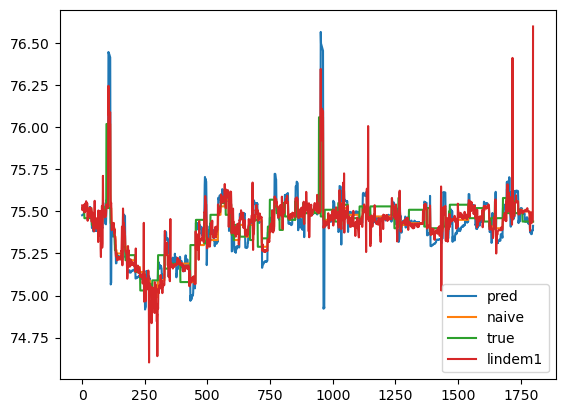

In [60]:
x_range = np.arange(y_true.shape[0])
plt.plot(x_range, predictions, label="pred")
plt.plot(x_range, naive, label="naive")
plt.plot(x_range, y_true, label="true")
plt.plot(x_range, lin_dem1, label="lindem1")
plt.legend()


In [ ]:
df

## Tick runs

In [10]:
w_scaler = lambda row: 1 - (np.minimum(100, row)/np.minimum(100, row).max())
fair_price = pd.DataFrame({'fair_price': np.full(df_instruments.index.shape[0], np.nan)}, index=df_instruments.index)
price_columns = [x for x in df_instruments.columns if x.startswith('price') ]
instrument = 'DE_q1'
print(f"\nProcessing {instrument}")
target_instrument = instrument
# target_instrument = column.split('_')[-1]
y = df_instruments['price_' + instrument]
mask = df_instruments.reindex(y.index)[price_columns].values > 0
W_m = consecutive_true_counter(~mask)
W_m = np.apply_along_axis(w_scaler, 0, W_m)
D = df_instruments.reindex(y.index)['func_' + target_instrument].fillna(0.0).values.reshape(-1, 1)
X = df_instruments.reindex(y.index)[price_columns]
X.iloc[0] = 0.0
X_fill = X.ffill()
change_mask = X_fill.diff(1).ffill().abs() > 0.001
X[change_mask] = X_fill.diff(1).ffill()[change_mask]
X[X > 10.0] = 0.0
X = X.ffill().values


w_size = 200
predictions = None #TODO


Processing DE_q1


In [41]:
df = df.reset_index(names='timestamp')
# Pivot so each row is a timestamp, each column is an instrument_tenor
df_mid = df.pivot(index='timestamp', columns='instrument_tenor', values='mid')

# Now, df_mid.shape[0] == number of unique timestamps (2000)
print(df_mid.shape)

(2000, 17)


In [42]:
df_price = df.pivot(index='timestamp', columns='instrument_tenor', values='price')

In [34]:
from Math.ti_class import TR_class

In [57]:
from Math.lm_class import kalman1d
from sklearn.linear_model import LinearRegression
ti_cls = TR_class(15, 15)

_WIN_SIZE = 200
target_column = 'DE_q1'
reg_columns = ['DE_m1', 'DE_m2', 'DE_y1']
idxs = []
results = {x: [] for x in reg_columns}
coefs = {x: [] for x in reg_columns}
target_bfill = df_price[target_column].bfill()
target_ffill = df_price[target_column].ffill()
for i in range(0, df_mid.shape[0]-_WIN_SIZE-1):
    data_arr = df_mid.iloc[i:i+_WIN_SIZE].diff().dropna()
    next_trade = target_bfill.iloc[i+_WIN_SIZE+1]
    last_trade = target_ffill.iloc[i+_WIN_SIZE]
    next_X = df_mid.diff().iloc[i+_WIN_SIZE+1]
    y_series = data_arr[target_column]
    for column in reg_columns:
        data_column = data_arr[column]
        idx_series = ti_cls.tick_imbalance_indices(data_column)
        data_aux = pd.concat([data_column, idx_series], axis=1).reset_index()
        data_aux = data_aux.groupby(0).agg('mean').set_index('index')
        y_aux = pd.concat([y_series, idx_series], axis=1).reset_index()
        y = y_aux.groupby(0).agg('mean')[target_column].values
        X = data_aux.values
        coef = LinearRegression().fit(X.reshape(-1, 1), y.reshape(-1, 1)).coef_
        fair_price = np.dot(coef, next_X[column]) + last_trade + np.sum(y)
        results[column].append(fair_price[0][0])
        coefs[column].append(coef[0][0])
    idxs.append(df_mid.iloc[i+_WIN_SIZE+1].index)

In [58]:
lin_dem1 = pd.Series(sum([[76.6]], results['DE_m1']))

In [59]:
lin_dem1

0       75.535860
1       75.507541
2       75.515305
3       75.515047
4       75.515111
          ...    
1795    75.436497
1796    75.435965
1797    75.446885
1798    75.448130
1799    76.600000
Length: 1800, dtype: float64

In [247]:
np.column_stack([X, y])

array([[ 0.00000000e+00,  8.56500000e+01],
       [-3.00000000e-03,  8.56500000e+01],
       [ 0.00000000e+00,  8.56700000e+01],
       [ 6.33333333e-03,  8.56800000e+01],
       [-1.17777778e-02,  8.56800000e+01],
       [-5.70000000e-03,  8.56800000e+01],
       [ 2.45454545e-03,  8.56800000e+01],
       [ 0.00000000e+00,  8.56800000e+01],
       [ 1.06611111e-01,  8.56800000e+01],
       [ 0.00000000e+00,  8.56800000e+01],
       [-1.05500000e-01,  8.57066667e+01],
       [ 0.00000000e+00,  8.57325000e+01],
       [ 0.00000000e+00,  8.57300000e+01],
       [ 0.00000000e+00,  8.57300000e+01],
       [ 0.00000000e+00,  8.57200000e+01],
       [ 0.00000000e+00,  8.57250000e+01],
       [-1.53846154e-03,  8.57400000e+01],
       [-7.69230769e-04,  8.56661538e+01],
       [ 8.75000000e-03,  8.61225000e+01],
       [ 0.00000000e+00,  8.64000000e+01],
       [-2.72727273e-03,  8.64000000e+01],
       [ 0.00000000e+00,  8.60057143e+01],
       [ 0.00000000e+00,  8.57100000e+01],
       [-9.

In [162]:
y.shape

(19,)

In [235]:
np.corrcoef(X, y.reshape(-1, 1), rowvar=False)

array([[ 1.00000000e+00, -8.32841706e-04],
       [-8.32841706e-04,  1.00000000e+00]])

In [254]:
df_hat = pd.DataFrame(results)

In [255]:
df_hat['y_true'] = target_bfill.iloc[201:].reset_index(drop=True)

In [151]:
df_hat['coef'] = pd.Series(coefs['DE_m1'])

In [261]:
df_hat['agg_mean'] = (df_hat['DE_m1'] + df_hat['DE_m2'] + df_hat['DE_q1']) / 3

<Axes: >

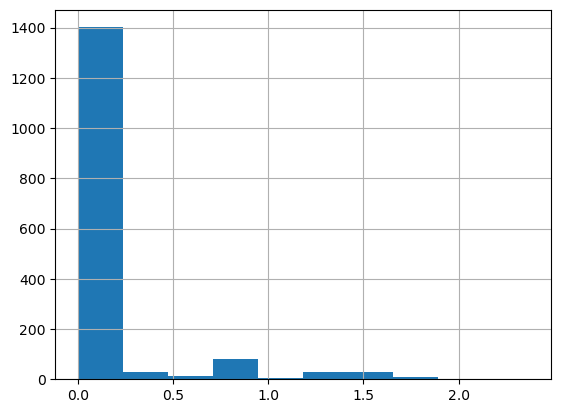

In [263]:
df_hat.eval('agg_mean - y_true').abs().hist()

In [146]:
df_mid.diff().corr()

instrument_tenor,DE_m1,DE_m2,DE_m3,DE_q1,DE_q2,DE_q3,DE_q4,DE_y1,DE_y2,FR_m1,FR_m2,FR_m3,FR_q1,FR_q2,FR_y1,IT_m1,IT_q1
instrument_tenor,,,,,,,,,,,,,,,,,
DE_m1,1.000000e+00,-8.931057e-08,-9.031634e-07,-7.371473e-07,-0.000002,-0.000003,-0.000005,-6.609833e-07,-0.000004,0.628718,-9.788555e-08,-0.000001,-0.000001,-0.000002,2.861594e-07,0.715147,-0.000003
DE_m2,-8.931057e-08,1.000000e+00,-3.128089e-06,-2.553096e-06,-0.000007,-0.000009,-0.000019,-2.289303e-06,-0.000013,-0.000002,8.294922e-01,-0.000004,-0.000004,-0.000007,9.911074e-07,-0.000004,-0.000010
DE_m3,-9.031634e-07,-3.128089e-06,1.000000e+00,-2.581847e-05,-0.000075,-0.000093,-0.000190,-2.315084e-05,-0.000132,-0.000024,-3.428426e-06,0.897503,-0.000038,-0.000071,1.002269e-05,-0.000045,-0.000099
DE_q1,-7.371473e-07,-2.553096e-06,-2.581847e-05,1.000000e+00,-0.000061,-0.000076,-0.000155,-1.889534e-05,-0.000107,-0.000019,-2.798226e-06,-0.000032,0.737341,-0.000058,8.180356e-06,-0.000037,0.649170
DE_q2,-2.148104e-06,-7.439917e-06,-7.523702e-05,-6.140724e-05,1.000000,-0.000221,-0.000451,-5.506248e-05,-0.000313,-0.000056,-8.154247e-06,-0.000093,-0.000091,0.728038,2.383819e-05,-0.000108,-0.000236
DE_q3,-2.656370e-06,-9.200286e-06,-9.303895e-05,-7.593689e-05,-0.000221,1.000000,-0.000557,-6.809088e-05,-0.000387,-0.000070,-1.008363e-05,-0.000115,-0.000112,-0.000208,2.947857e-05,-0.000133,-0.000292
DE_q4,-5.410769e-06,-1.874010e-05,-1.895114e-04,-1.546761e-04,-0.000451,-0.000557,1.000000,-1.386946e-04,-0.000789,-0.000142,-2.053939e-05,-0.000235,-0.000228,-0.000423,6.004501e-05,-0.000272,-0.000595
DE_y1,-6.609833e-07,-2.289303e-06,-2.315084e-05,-1.889534e-05,-0.000055,-0.000068,-0.000139,1.000000e+00,-0.000096,-0.000017,-2.509106e-06,-0.000029,-0.000028,-0.000052,7.555458e-01,-0.000033,-0.000073
DE_y2,-3.759289e-06,-1.302022e-05,-1.316685e-04,-1.074657e-04,-0.000313,-0.000387,-0.000789,-9.636207e-05,1.000000,-0.000099,-1.427034e-05,-0.000163,-0.000159,-0.000294,4.171801e-05,-0.000189,-0.000413
